# CRLB-Based InSAR Workflow Tutorial

This notebook demonstrates how to run the **CRLB-based coherence path** with the current `insar_pipeline` codebase and visualize each key generated artifact.

Workflow:
1. Crop (`lat/lon` + interferogram files)
2. Build dataset with `coherence_source="computed_crlb"`
3. Train/predict
4. Compute score
5. Generate geocoded outputs

At each stage, we plot generated files (`.npy` via `matplotlib`, `.rdr/.cor` via GDAL).

In [18]:
# --- Configuration (edit these paths before running) ---
from pathlib import Path

BASE_DIR = Path('/data6/WORKDIR/AmatriceSenDT22/merged/interferograms')
GEOM_REFERENCE_DIR = Path('/data6/WORKDIR/AmatriceSenDT22/merged/geom_reference')
OUTPUT_DIR = BASE_DIR / 'cropped'
STACK_ROOT = BASE_DIR  # set this to your stack root if different
NEXT_DATE = '20160821_20160902'

LAT_MIN, LAT_MAX = 42.625, 42.635
LON_MIN, LON_MAX = 13.28, 13.30

print('BASE_DIR:', BASE_DIR)
print('GEOM_REFERENCE_DIR:', GEOM_REFERENCE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


BASE_DIR: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms
GEOM_REFERENCE_DIR: /data6/WORKDIR/AmatriceSenDT22/merged/geom_reference
OUTPUT_DIR: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped


In [19]:
# --- Imports ---
import pickle
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

from insar_pipeline.preprocess import CropConfig, batch_crop_filt_fine_cor
from insar_pipeline.dataset_builder import DatasetConfig, build_and_save_dataset
from insar_pipeline.modeling import TrainingConfig, run_training_and_prediction
from insar_pipeline.scoring import ScoreConfig, compute_and_save_score
from insar_pipeline.output_products import OutputConfig, generate_geocoded_outputs


In [20]:
# --- Visualization helpers ---
def show_npy(path, title=None, cmap='viridis'):
    arr = np.load(path)
    if arr.ndim == 3:
        arr2d = arr[:, :, 0]
    else:
        arr2d = arr

    plt.figure(figsize=(7, 3.5))
    im = plt.imshow(arr2d, cmap=cmap)
    plt.colorbar(im, shrink=0.8)
    plt.title(title or f'{path.name} | shape={arr.shape} | dtype={arr.dtype}')
    plt.tight_layout()
    plt.show()


def show_raster(path, band=1, title=None, cmap='viridis'):
    ds = gdal.Open(str(path), gdal.GA_ReadOnly)
    if ds is None:
        raise FileNotFoundError(f'Cannot open raster: {path}')
    arr = ds.GetRasterBand(band).ReadAsArray()

    plt.figure(figsize=(7, 3.5))
    im = plt.imshow(arr, cmap=cmap)
    plt.colorbar(im, shrink=0.8)
    plt.title(title or f'{path.name} (band {band}) | shape={arr.shape} | dtype={arr.dtype}')
    plt.tight_layout()
    plt.show()


## 1) Crop input files and inspect cropped `lat/lon`

In [21]:
crop_outputs = batch_crop_filt_fine_cor(
    CropConfig(
        base_path=BASE_DIR,
        geom_reference_path=GEOM_REFERENCE_DIR,
        output_base_path=OUTPUT_DIR,
        lat_min=LAT_MIN,
        lat_max=LAT_MAX,
        lon_min=LON_MIN,
        lon_max=LON_MAX,
    )
)
print('Number of cropped interferogram files:', len(crop_outputs))
print('Example output:', crop_outputs[0] if crop_outputs else 'None')

lat_file = OUTPUT_DIR / 'lat_cropped.rdr'
lon_file = OUTPUT_DIR / 'lon_cropped.rdr'
print('lat_file:', lat_file)
print('lon_file:', lon_file)


Number of cropped interferogram files: 30
Example output: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/20160306_20160330_filt_fine.cor
lat_file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/lat_cropped.rdr
lon_file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/lon_cropped.rdr


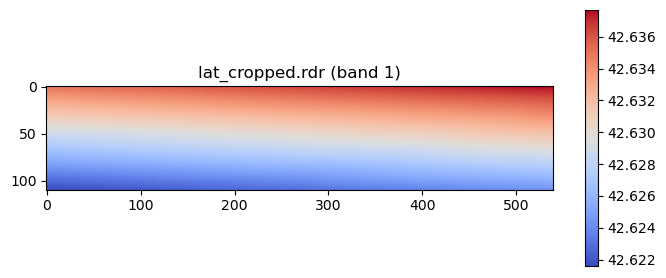

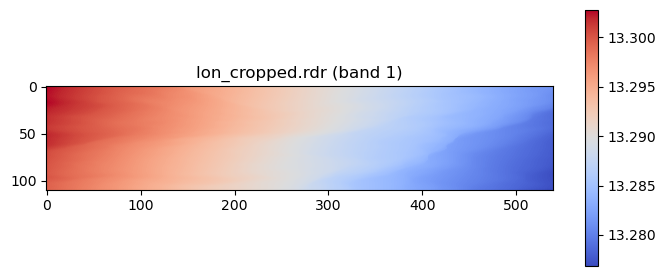

In [22]:
show_raster(lat_file, band=1, title='lat_cropped.rdr (band 1)', cmap='coolwarm')
show_raster(lon_file, band=1, title='lon_cropped.rdr (band 1)', cmap='coolwarm')


## 2) Build dataset with CRLB coherence and visualize saved `.npy` files

In [23]:
dataset_dir = build_and_save_dataset(
    DatasetConfig(
        cropped_dir=OUTPUT_DIR,
        output_dir=OUTPUT_DIR,
        input_source='stack_int',
        stack_root=STACK_ROOT,
        coherence_source='computed_crlb',
        persist_computed_cor=True,
    )
)
print('dataset_dir:', dataset_dir)


dataset_dir: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/dataset


In [24]:
for name in ['data.npy', 'data_std.npy', 'geninue.npy', 'geninue_std.npy']:
    p = dataset_dir / name
    print(name, 'exists =', p.exists())
    if p.exists():
        arr = np.load(p, mmap_mode='r')
        print('   shape:', arr.shape, 'dtype:', arr.dtype)

with open(dataset_dir / 'dates.pkl', 'rb') as f:
    dates = pickle.load(f)
print('dates length:', len(dates), 'sample:', dates[:3])


data.npy exists = True
   shape: (110, 540, 9) dtype: float32
data_std.npy exists = True
   shape: (110, 540, 9) dtype: float32
geninue.npy exists = True
   shape: (110, 540) dtype: float32
geninue_std.npy exists = True
   shape: (110, 540, 1) dtype: float32
dates length: 9 sample: ['20160306_20160330', '20160330_20160517', '20160517_20160529']


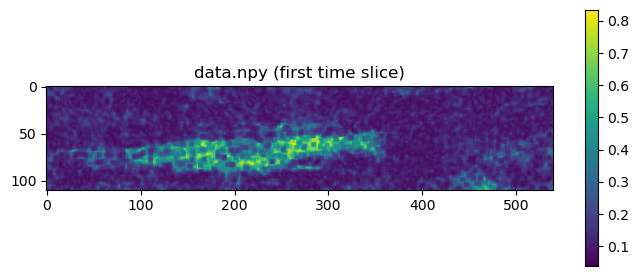

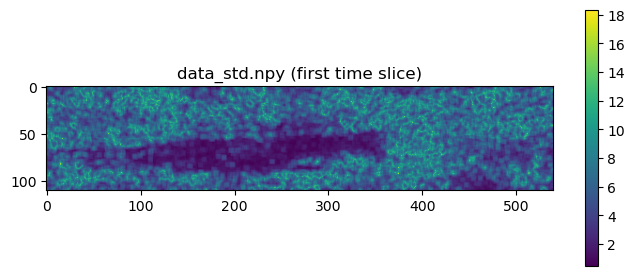

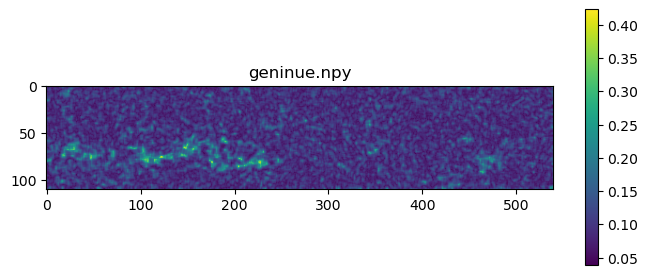

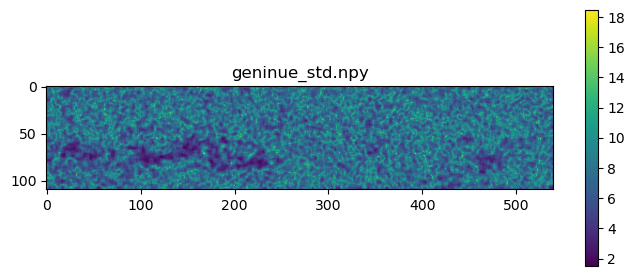

In [25]:
show_npy(dataset_dir / 'data.npy', title='data.npy (first time slice)')
show_npy(dataset_dir / 'data_std.npy', title='data_std.npy (first time slice)')
show_npy(dataset_dir / 'geninue.npy', title='geninue.npy')
show_npy(dataset_dir / 'geninue_std.npy', title='geninue_std.npy')


## 3) Train/predict and visualize `future_predictions.npy`

In [ ]:
predict_dir = run_training_and_prediction(
    TrainingConfig(
        dataset_dir=dataset_dir,
        output_dir=OUTPUT_DIR,
        next_date=NEXT_DATE,
    )
)
print('predict_dir:', predict_dir)


/data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/future_predictions.npy exists = True
shape: (110, 540) dtype: float32


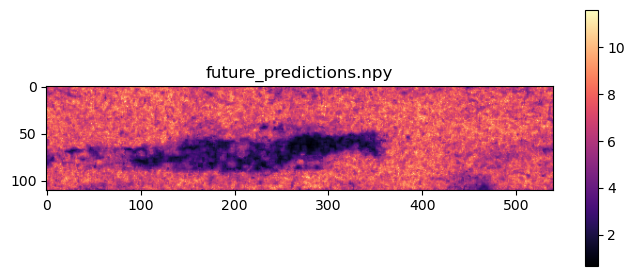

In [ ]:
fp = predict_dir / 'future_predictions.npy'
print(fp, 'exists =', fp.exists())
if fp.exists():
    arr = np.load(fp, mmap_mode='r')
    print('shape:', arr.shape, 'dtype:', arr.dtype)
show_npy(fp, title='future_predictions.npy', cmap='magma')


## 4) Compute score and visualize `score.npy`

In [ ]:
score_path = compute_and_save_score(
    ScoreConfig(
        dataset_dir=dataset_dir,
        predict_dir=predict_dir,
        score_filename='score.npy',
    )
)
print('score_path:', score_path)


score_path: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/score.npy


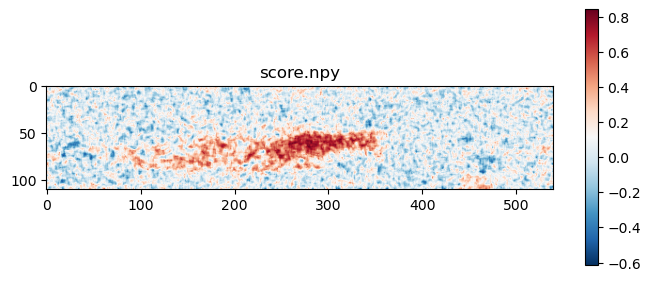

In [ ]:
show_npy(score_path, title='score.npy', cmap='RdBu_r')


## 5) Generate geocoded outputs and visualize `.cor` products

In [ ]:
output_files = generate_geocoded_outputs(
    OutputConfig(
        predict_dir=predict_dir,
        lat_file=lat_file,
        lon_file=lon_file,
        subset_params='-l 42.625 42.635 -L 13.28 13.30',
    )
)
print('Generated output files:')
for p in output_files:
    print(' -', p)


write file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/score.cor
write file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/score.cor.xml
write file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/score.cor.vrt
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00014761828501290138, 4.800396637925411e-05)
output area extent in (S, N, W, E) in degree: (42.62151966619929, 42.63775767755071, 13.276840049835657, 13.302762191680454)
output file row / column number: (110, 540)
[1/1] preparing geometry for dest_box: (0, 0, 540, 110) --> full src_box: (0, 0, 540, 110

/home/yangyc/.conda/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


Generated output files:
 - /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/scorefinal.tif


2026-03-09 20:41:25,288 - fiona._env - DEBUG - GDAL_DATA found in environment.
2026-03-09 20:41:25,291 - fiona._env - DEBUG - PROJ_DATA found in environment.
2026-03-09 20:41:25,350 - numexpr.utils - INFO - Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
2026-03-09 20:41:25,351 - numexpr.utils - INFO - Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.


run view.py in MintPy version 1.6.1, date 2024-07-31
input file is isce .cor file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/geo_score.cor in float32 format
file size in y/x: (110, 540)
num of datasets in file geo_score.cor: 1
datasets to exclude (0):
[]
datasets to display (1):
['band1']
data   coverage in y/x: (0, 0, 540, 110)
subset coverage in y/x: (0, 0, 540, 110)
data   coverage in lat/lon: (13.276840049835657, 42.63775767755071, 13.302762191680454, 42.62151966619929)
subset coverage in lat/lon: (13.276840049835657, 42.63775767755071, 13.302762191680454, 42.62151966619929)
------------------------------------------------------------------------
colormap: gray
figure title: geo_score.cor
figure size : [10.0, 5.0]
reading data ...
data    range: [-0.6170165, 0.84292114] 1
display range: [0.0, 1.0] 1
display data in transparency: 1.0
plot in geo-coordinate
plotting data as image via matplotlib.pyplot.imshow ...
plot scale bar: [0.2, 0.2, 0.1]
showing ...


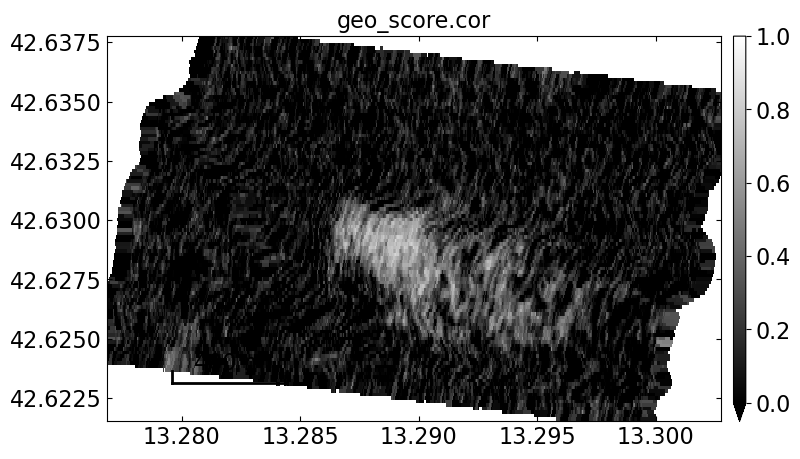

In [ ]:

from mintpy.cli import view

view.main('/data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/geo_score.cor' .split())

run view.py in MintPy version 1.6.1, date 2024-07-31
input file is isce .cor file: /data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/scorefinal.cor in float32 format
file size in y/x: (68, 417)
num of datasets in file scorefinal.cor: 1
datasets to exclude (0):
[]
datasets to display (1):
['band1']
data   coverage in y/x: (0, 0, 417, 68)
subset coverage in y/x: (0, 0, 417, 68)
data   coverage in lat/lon: (13.27996030765031, 42.635100548420475, 13.299977961630457, 42.625062505039594)
subset coverage in lat/lon: (13.27996030765031, 42.635100548420475, 13.299977961630457, 42.625062505039594)
------------------------------------------------------------------------
colormap: gray
figure title: scorefinal.cor
figure size : [10.0, 4.0]
reading data ...
data    range: [-0.57224476, 0.84292114] 1
display range: [0.0, 1.0] 1
display data in transparency: 1.0
plot in geo-coordinate
plotting data as image via matplotlib.pyplot.imshow ...
plot scale bar: [0.2, 0.2, 0.1]
showing ..

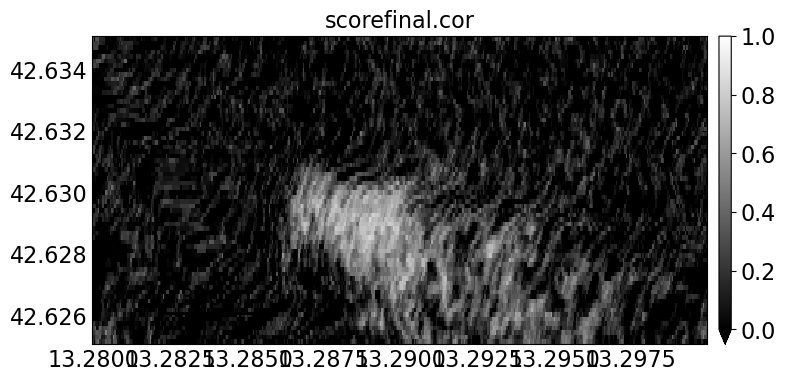

In [ ]:

from mintpy.cli import view

view.main('/data6/WORKDIR/AmatriceSenDT22/merged/interferograms/cropped/predict/scorefinal.cor' .split())

## Notes

- This notebook focuses on the **CRLB** path (`coherence_source='computed_crlb'`).
- If your stack root differs from `BASE_DIR`, update `STACK_ROOT` accordingly.
- If geocoding tools (`geocode.py`, `subset.py`, `save_gdal.py`) are unavailable, run the output stage inside your MintPy/ISCE environment.